# Building Footprint Analysis: Dasymetric Population Disaggregation

This notebook uses Google Open Buildings v3 footprints as an independent covariate
to disaggregate estimated SAL-level population (from the step-down model) to
individual building footprints. Population is allocated proportional to building
footprint area within each SAL.

**Methodology**: Area-weighted dasymetric mapping (Mennis 2003; Langford 2007).
Building footprint area serves as the sole weighting covariate to avoid circularity
with the 2011 population data already used in the step-down model.

**Key limitation**: This approach assumes population density is proportional to
building footprint area, which may not hold for commercial/industrial structures.
A minimum area filter is tested to exclude small non-residential artifacts.

In [1]:
# IMPORTS
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely import wkt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import contextily as cx

In [2]:
# CONFIGURATION
# All file paths and parameters are defined here for reproducibility.
import warnings
warnings.filterwarnings("ignore")

# File path for population estimates at SAL level (output of step-down model).
POP_FILE = "data/pop_pred_final.csv"

# File path for SAL polygon geometries.
SAL_SHAPEFILE = "data/2011_census/2011_census/ea_sal_kzn_gp.dbf"

# File path for Google Open Buildings v3 footprints (CSV with WKT geometry).
GAUTENG_BLDGS_FILE = "data/open_buildings_gauteng/open_buildings_gauteng.csv"
KZN_BLDGS_FILE = "data/open_buildings_KZN/open_buildings_KZN.csv"

# Projected CRS for area calculations (UTM Zone 35S).
PROJECTED_CRS = "EPSG:32735"

# Minimum building area filters to test (in square meters).
AREA_FILTERS_M2 = [0, 5, 10, 15, 20, 25, 30, 35, 40]

# Column names for SAL population and SAL identifier.
SAL_POP_COL = "sal2023_est"
SAL_ID_COL = "EA_CODE"

## LOAD DATA

In [3]:
# LOAD POPULATION DATA
# The step-down model output is a CSV with SAL-level population estimates.
pop_df = pd.read_csv(POP_FILE)

print(f"POPULATION RECORDS: {len(pop_df)}")
print(f"COLUMNS: {list(pop_df.columns)}\n")
pop_df.head()

POPULATION RECORDS: 38380
COLUMNS: ['WardID', 'EA_CODE', 'sal2011_pop', 'ward2023_pop', 'EA_GTYPE', 'EA_TYPE', 'econ_status', 'houses2011', 'Black_Afri', 'White', 'Coloured', 'Indian_or', 'Other', 'area_km2', 'sal_dense', 'log_density', 'ward2011_sum', 'share2011', 'dasym_weight', 'sal2023_est', 'growth_rate']



,WardID,EA_CODE,sal2011_pop,ward2023_pop,EA_GTYPE,EA_TYPE,econ_status,houses2011,Black_Afri,White,...,Indian_or,Other,area_km2,sal_dense,log_density,ward2011_sum,share2011,dasym_weight,sal2023_est,growth_rate
0,52103007,50310272,559.0,5887,Traditional,Traditional residential,Non_Wealthy,131.0,558.0,0.0,...,1.0,0.0,6.072531,92.053872,4.533179,7387.0,0.075673,0.066565,391.868711,-0.029168
1,52103007,50310271,713.0,5887,Traditional,Traditional residential,Non_Wealthy,167.0,713.0,0.0,...,0.0,0.0,3.900819,182.782137,5.213751,7387.0,0.096521,0.097650,574.864868,-0.017785
2,52103007,50310262,443.0,5887,Traditional,Traditional residential,Non_Wealthy,135.0,443.0,0.0,...,0.0,0.0,1.926623,229.935961,5.442140,7387.0,0.059970,0.063329,372.820189,-0.014270
3,52103007,50310266,743.0,5887,Traditional,Traditional residential,Non_Wealthy,154.0,740.0,0.0,...,1.0,1.0,1.706669,435.350859,6.078447,7387.0,0.100582,0.118635,698.405054,-0.005145
4,52103006,50310265,339.0,7902,Traditional,Traditional residential,Non_Wealthy,92.0,339.0,0.0,...,0.0,0.0,4.054491,83.610997,4.438064,8923.0,0.037992,0.034488,272.526930,-0.018024


In [4]:
# LOAD SAL POLYGONS
# SAL geometries provide the spatial boundaries for population allocation.
sal_gdf = gpd.read_file(SAL_SHAPEFILE)
sal_gdf = sal_gdf.to_crs(PROJECTED_CRS)

print(f"SAL POLYGONS: {len(sal_gdf)}")
print(f"CRS: {sal_gdf.crs}\n")
sal_gdf.head()

SAL POLYGONS: 39177
CRS: EPSG:32735



,OBJECTID,EA_CODE,SP_CODE,SP_NAME,MP_CODE,MP_NAME,MN_MDB_C,MN_CODE,MN_NAME,MN_TYPE,...,45_49,50_54,55_59,60_64,65_69,70_74,75_79,80_84,85+,geometry
0,28217,50310272.0,503001001.0,KwaMaqikizane SP,503001.0,KwaMaqikizane,KZN213,503.0,Umzumbe,CATB,...,27,23,14,13,10,9,4,6,2,"POLYGON ((822771.595 6638453.565, 822700.341 6..."
1,28623,50310271.0,503001001.0,KwaMaqikizane SP,503001.0,KwaMaqikizane,KZN213,503.0,Umzumbe,CATB,...,30,25,21,33,19,8,7,3,3,"POLYGON ((819493.415 6637587.969, 819492.481 6..."
2,28431,50310262.0,503002001.0,Mthwalume SP,503002.0,Mthwalume,KZN213,503.0,Umzumbe,CATB,...,17,17,25,10,4,5,4,6,3,"POLYGON ((824803.527 6636980.442, 824776.674 6..."
3,28241,50310266.0,503002001.0,Mthwalume SP,503002.0,Mthwalume,KZN213,503.0,Umzumbe,CATB,...,31,21,28,22,15,7,8,10,4,"POLYGON ((823795.835 6638400.097, 823789.875 6..."
4,28287,50310265.0,503003001.0,Ngomakazi SP,503003.0,Ngomakazi,KZN213,503.0,Umzumbe,CATB,...,19,14,8,11,12,1,4,6,1,"POLYGON ((823864.034 6636374.407, 823832.145 6..."


In [5]:
# MERGE POPULATION ESTIMATES INTO SAL POLYGONS
# Join the step-down population estimates to the SAL geometry layer.
pop_gdf = sal_gdf.merge(pop_df[[SAL_ID_COL, SAL_POP_COL]], on = SAL_ID_COL, how = "left")

# Fill missing population estimates with zero.
pop_gdf[SAL_POP_COL] = pop_gdf[SAL_POP_COL].fillna(0)

print(f"MERGED RECORDS: {len(pop_gdf)}")
print(f"TOTAL ESTIMATED POPULATION: {pop_gdf[SAL_POP_COL].sum():,.0f}")
print(f"SALs WITH ZERO POPULATION: {(pop_gdf[SAL_POP_COL] == 0).sum()}")

MERGED RECORDS: 39177
TOTAL ESTIMATED POPULATION: 24,958,077
SALs WITH ZERO POPULATION: 5505


In [6]:
# LOAD BUILDING FOOTPRINTS
# Google Open Buildings CSV contains WKT geometry in a "geometry" column.
# Using pd.read_csv() instead of gpd.read_file() to avoid encoding errors.
gauteng_bldg_df = pd.read_csv(GAUTENG_BLDGS_FILE)
gauteng_bldg_df["province"] = "Gauteng"

kzn_bldg_df = pd.read_csv(KZN_BLDGS_FILE)
kzn_bldg_df["province"] = "KwaZulu-Natal"

bldg_df = pd.concat([gauteng_bldg_df, kzn_bldg_df], ignore_index = True)

print(f"RAW BUILDING RECORDS: {len(bldg_df)}")
print(f"COLUMNS: {list(bldg_df.columns)}\n")
bldg_df.head(3)

RAW BUILDING RECORDS: 15430659
COLUMNS: ['latitude', 'longitude', 'area_in_meters', 'confidence', 'geometry', 'full_plus_code', 'province']



,latitude,longitude,area_in_meters,confidence,geometry,full_plus_code,province
0,-25.593295,27.159420,45.9673,0.8455,"POLYGON((27.1594695585726 -25.5932870056484, 2...",5G69C545+MQM3,Gauteng
1,-25.588353,27.173109,5.8648,0.6633,"POLYGON((27.1731221531997 -25.5883631751489, 2...",5G69C56F+M65V,Gauteng
2,-25.734390,27.166579,18.3057,0.7028,"POLYGON((27.1666092166818 -25.7343827735225, 2...",5G697588+6JWG,Gauteng


In [7]:
# CONVERT BUILDING DATA TO GEODATAFRAME
# Parse WKT strings into shapely geometry objects.
bldg_df["geometry"] = bldg_df["geometry"].apply(wkt.loads)

# Convert to GeoDataFrame with WGS84 (Open Buildings default CRS).
bldg_gdf = gpd.GeoDataFrame(bldg_df, geometry = "geometry", crs = "EPSG:4326")

# Reproject to the projected CRS for accurate area calculations.
bldg_gdf = bldg_gdf.to_crs(PROJECTED_CRS)

print(f"BUILDING FOOTPRINTS LOADED: {len(bldg_gdf)}")
print(f"CRS: {bldg_gdf.crs}")

BUILDING FOOTPRINTS LOADED: 15430659
CRS: EPSG:32735


In [8]:
# COMPUTE BUILDING FOOTPRINT AREA
# Calculate each footprint area in square meters from the projected geometry.
bldg_gdf["bldg_area_m2"] = bldg_gdf.geometry.area

print(f"BUILDING AREA STATS (m2):")
print(bldg_gdf["bldg_area_m2"].describe().round(2))

BUILDING AREA STATS (m2):
count    15430659.00
mean           64.47
std           190.06
min             2.50
25%            20.16
50%            36.15
75%            64.36
max         49674.27
Name: bldg_area_m2, dtype: float64


## VISUALIZE BUILDING FOOTPRINTS

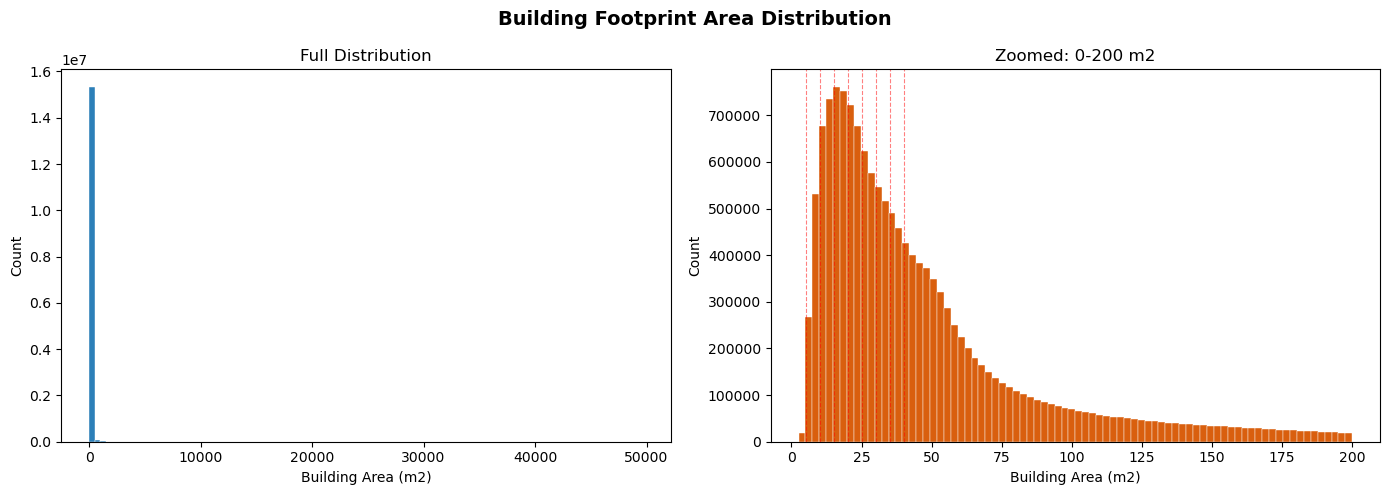

In [9]:
# BUILDING AREA DISTRIBUTION
# Histogram of building footprint areas to identify reasonable area filters.
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Full distribution.
axes[0].hist(bldg_gdf["bldg_area_m2"], bins = 100, color = "#2c7fb8", edgecolor = "white", linewidth = 0.3)
axes[0].set_xlabel("Building Area (m2)")
axes[0].set_ylabel("Count")
axes[0].set_title("Full Distribution")

# Zoomed distribution (0-200 m2) to see small building detail.
small_bldgs = bldg_gdf[bldg_gdf["bldg_area_m2"] <= 200]
axes[1].hist(small_bldgs["bldg_area_m2"], bins = 80, color = "#d95f0e", edgecolor = "white", linewidth = 0.3)
axes[1].set_xlabel("Building Area (m2)")
axes[1].set_ylabel("Count")
axes[1].set_title("Zoomed: 0-200 m2")

# Add vertical lines for each filter threshold.
for f in AREA_FILTERS_M2:
    if f > 0 and f <= 200:
        axes[1].axvline(x = f, color = "red", linestyle = "--", alpha = 0.5, linewidth = 0.8)

plt.suptitle("Building Footprint Area Distribution", fontsize = 14, fontweight = "bold")
plt.tight_layout()
plt.savefig("images/building_footprint_analysis/building_area_distribution.png", dpi = 300, bbox_inches = "tight")
plt.show()

SALs with buildings: 23520
Top SAL has 14698.0 buildings
Selected SAL: 59912327.0


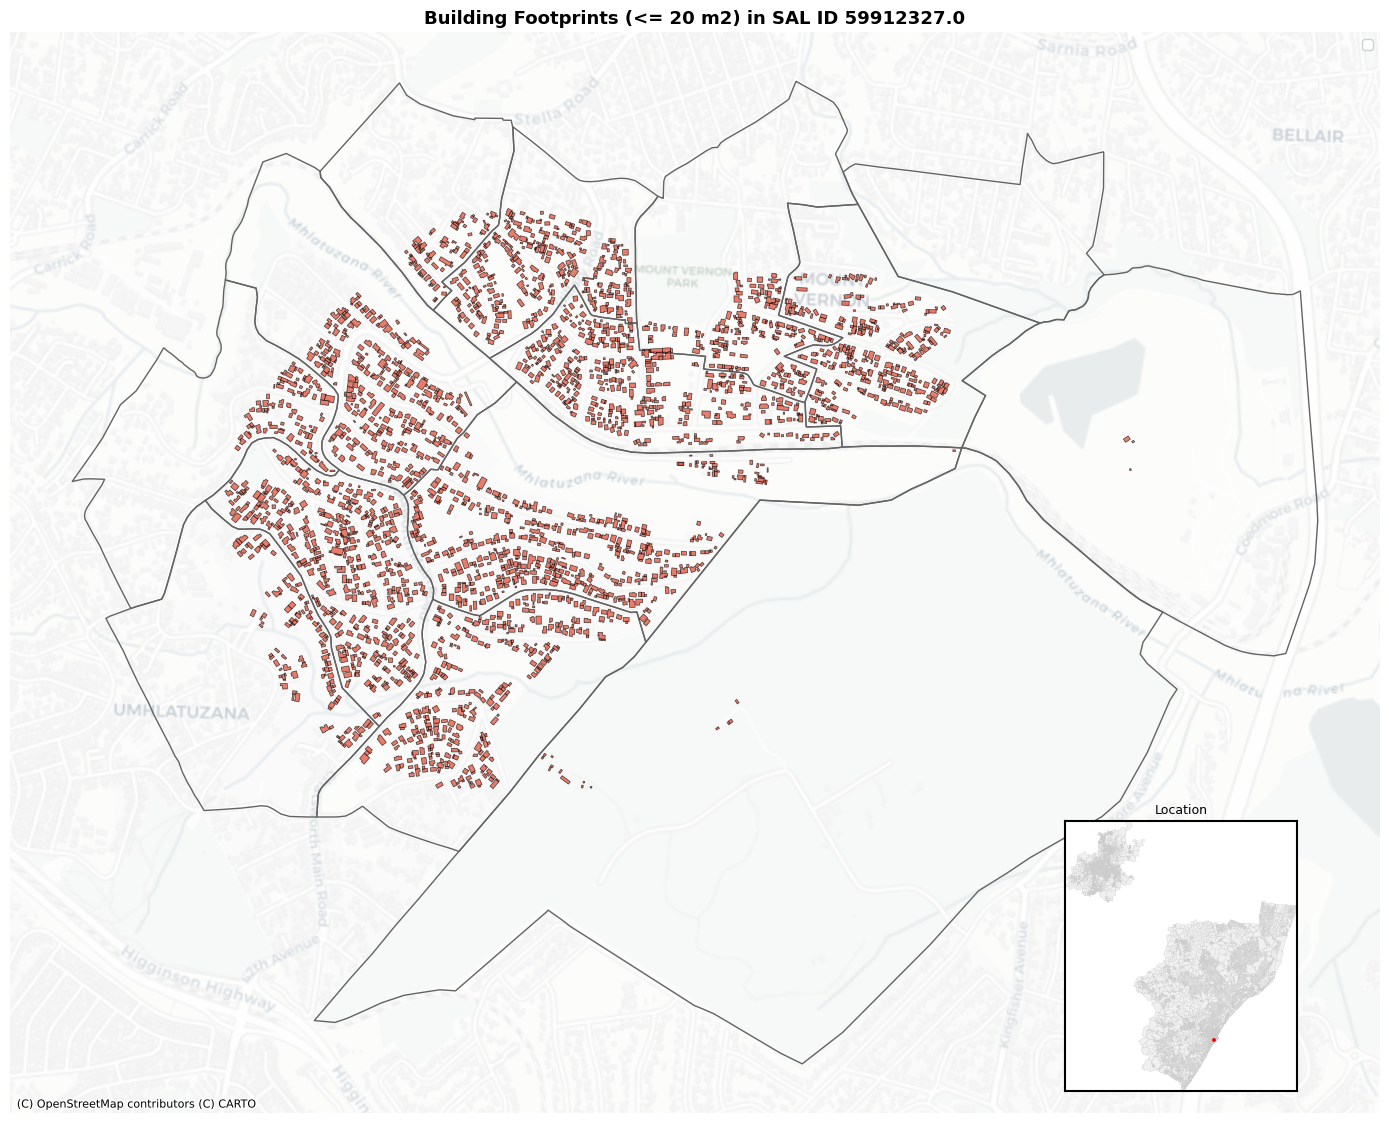


SAMPLE CONTAINS 14 SALs AND 3086 BUILDINGS


In [ ]:
# MAP: SAMPLE AREA SHOWING BUILDINGS OVERLAID ON SAL BOUNDARIES
# Spatial join to find SALs that contain buildings,
# then select one SAL with a good number of buildings for viz.
# Filter buildings by minimum area first for performance.
bldg_filtered = bldg_gdf[bldg_gdf["bldg_area_m2"] >= 20].copy()

# Spatial join to count buildings per SAL.
bldg_with_sal = gpd.sjoin(bldg_filtered, pop_gdf[[SAL_ID_COL, "geometry"]], how = "inner", predicate = "within")

# Count buildings per SAL.
bldg_counts = bldg_with_sal.groupby(SAL_ID_COL).size().reset_index(name = "n_buildings")
bldg_counts = bldg_counts.sort_values("n_buildings", ascending = False)

print(f"SALs with buildings: {len(bldg_counts)}")
print(f"Top SAL has {bldg_counts.iloc[0]['n_buildings']} buildings")

# Target around 100-500 buildings for good visualization.
target_sals = bldg_counts[(bldg_counts["n_buildings"] >= 100) & (bldg_counts["n_buildings"] <= 500)]
if len(target_sals) == 0:
    # If no SAL in that range, just use the median.
    target_sal_id = bldg_counts.iloc[len(bldg_counts) // 2][SAL_ID_COL]
else:
    target_sal_id = target_sals.iloc[0][SAL_ID_COL]

print(f"Selected SAL: {target_sal_id}")

# Get the target SAL geometry and create a buffer for context (include neighboring SALs).
target_sal_geom = pop_gdf[pop_gdf[SAL_ID_COL] == target_sal_id].geometry.iloc[0]
sample_bounds = target_sal_geom.buffer(500) # 500m buffer to capture neighbors.

# Clip SALs and buildings to the sample window.
sal_sample = pop_gdf[pop_gdf.intersects(sample_bounds)].copy()
bldg_sample = bldg_filtered[bldg_filtered.intersects(sample_bounds)].copy()

# Create the map with inset.
fig, ax = plt.subplots(1, 1, figsize = (14, 14))

# Plot SALs and buildings first to establish the extent.
sal_sample.plot(ax = ax, facecolor = "none", edgecolor = "#636363", linewidth = 1.0, label = "SAL Boundaries")
bldg_sample.plot(ax = ax, facecolor = "#e34a33", edgecolor = "#000000", alpha = 0.7, linewidth = 0.5, label = "Buildings")

# Add basemap after plotting.
cx.add_basemap(ax, crs = sal_sample.crs, source = cx.providers.CartoDB.Positron, alpha = 0.5)

ax.set_title(f"Building Footprints (<= 20 m2) in SAL ID {target_sal_id}", fontsize = 13, fontweight = "bold")
ax.set_axis_off()
ax.legend(loc = "upper right", framealpha = 0.9)

# Create inset map showing context (location within provinces).
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
inset_ax = inset_axes(ax, width = "25%", height = "25%", loc = "lower right", 
                      bbox_to_anchor = (-0.02, 0.02, 1, 1), bbox_transform = ax.transAxes, 
                      borderpad = 0)

# Set white background and black border for inset.
inset_ax.set_facecolor("white")
inset_ax.patch.set_alpha(1.0)
for spine in inset_ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.5)
    spine.set_visible(True)

# Plot all SALs in gray for context.
pop_gdf.plot(ax = inset_ax, facecolor = "#f0f0f0", edgecolor = "#cccccc", linewidth = 0.2)

# Highlight the mapped area with a red rectangle.
from shapely.geometry import box
minx_sample, miny_sample, maxx_sample, maxy_sample = sal_sample.total_bounds
sample_bbox = box(minx_sample, miny_sample, maxx_sample, maxy_sample)
gpd.GeoSeries([sample_bbox], crs = sal_sample.crs).plot(ax = inset_ax, facecolor = "none", 
                                                          edgecolor = "red", linewidth = 2)

inset_ax.set_xlim(pop_gdf.total_bounds[0], pop_gdf.total_bounds[2])
inset_ax.set_ylim(pop_gdf.total_bounds[1], pop_gdf.total_bounds[3])
inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_ax.set_title("Location", fontsize = 9, pad = 5)

plt.tight_layout()
plt.savefig("images/building_footprint_analysis/building_sample_map.png", dpi = 300, bbox_inches = "tight")
plt.show()

print(f"\nSAMPLE CONTAINS {len(sal_sample)} SALs AND {len(bldg_sample)} BUILDINGS")

## NOTES

- Footprint area does not account for building height or number of floors.

- Google Open Buildings has known coverage gaps in dense informal settlements and rural areas, which are precisely the areas where population estimates matter most for healthcare access.

- UTM Zone 35S is centered on 27°E, which is well-suited for KwaZulu-Natal but introduces some area distortion for western Gauteng.